# Step 3: Frequency Analysis & Plots

**Kernel:** Python (ml-env) -- `C:\ml-env\Scripts\python.exe`

Analysis pass over `word_counts.parquet` before anything gets loaded into the
database. Answers: which words actually show up most, how does that break
down by HSK level / source type, how good is the wordlist match coverage,
and which frequent words are missing from the official wordlist entirely.

**Input:**
- `data/processed/word_counts.parquet` (102,315 rows, from notebook 02)
- `data/processed/hsk_wordlist.parquet` (7,410 words, from notebook 01)

**Output:** PNG figures saved to `data/plots/`, plus `data/processed/top_words_summary.csv`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

PROCESSED_DIR = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed")
PLOTS_DIR     = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_parquet(PROCESSED_DIR / "word_counts.parquet")
df_wordlist = pd.read_parquet(PROCESSED_DIR / "hsk_wordlist.parquet")
print("word_counts:", df.shape)
print("hsk_wordlist:", df_wordlist.shape)
df.head()


word_counts: (102315, 9)
hsk_wordlist: (7410, 8)


,word,level,exam_id,hsk_level,source_type,count,match_pattern,effective_level,match_type
0,大家,2.0,H30000,3,listening,2,NaN,2.0,direct
1,好,1.0,H30000,3,listening,10,NaN,1.0,direct
2,欢迎,2.0,H30000,3,listening,4,NaN,2.0,direct
3,参加,2.0,H30000,3,listening,2,NaN,2.0,direct
4,三级,NaN,H30000,3,listening,2,numeral_plus_unit,2.0,decomposed


## 1 -- Top 10 most frequent words overall

,word,total_count,effective_level
5592,的,12518,1.0
812,了,9069,1.0
3906,我,6756,1.0
1161,你,4940,1.0
4513,是,4297,1.0
5522,男,3043,1.0
2965,女,2990,1.0
1005,什么,2836,1.0
2040,去,2745,1.0
2572,在,2696,1.0


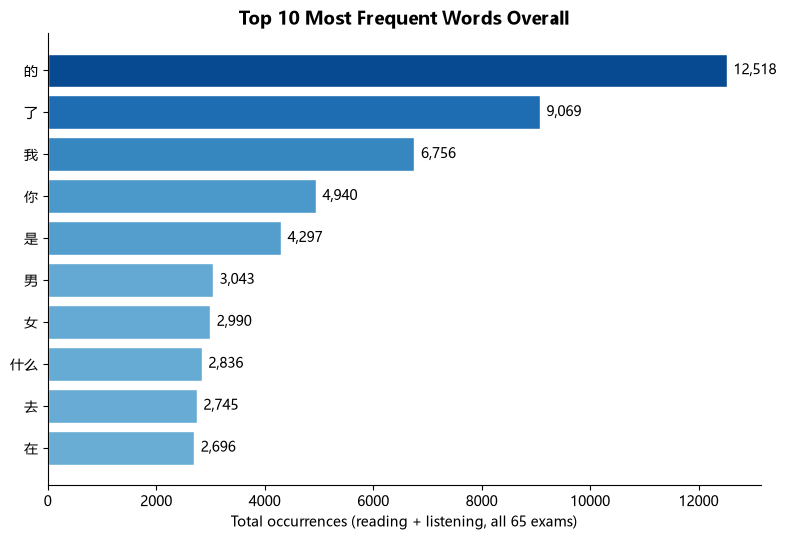

In [2]:
agg = (
    df.groupby("word", as_index=False)
    .agg(total_count=("count", "sum"), effective_level=("effective_level", "first"))
)
top10 = agg.sort_values("total_count", ascending=False).head(10)
display(top10)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = plt.cm.Blues(0.4 + 0.5 * (top10["total_count"] / top10["total_count"].max()))
bars = ax.barh(top10["word"][::-1], top10["total_count"][::-1], color=colors[::-1], edgecolor="white")
for rect in bars:
    w = rect.get_width()
    ax.text(w + top10["total_count"].max() * 0.01, rect.get_y() + rect.get_height() / 2,
            f"{int(w):,}", va="center", fontsize=10)
ax.set_xlabel("Total occurrences (reading + listening, all 65 exams)")
ax.set_title("Top 10 Most Frequent Words Overall", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_top10_overall.png", dpi=150)
plt.show()


## 2 -- Top 10 words per HSK level

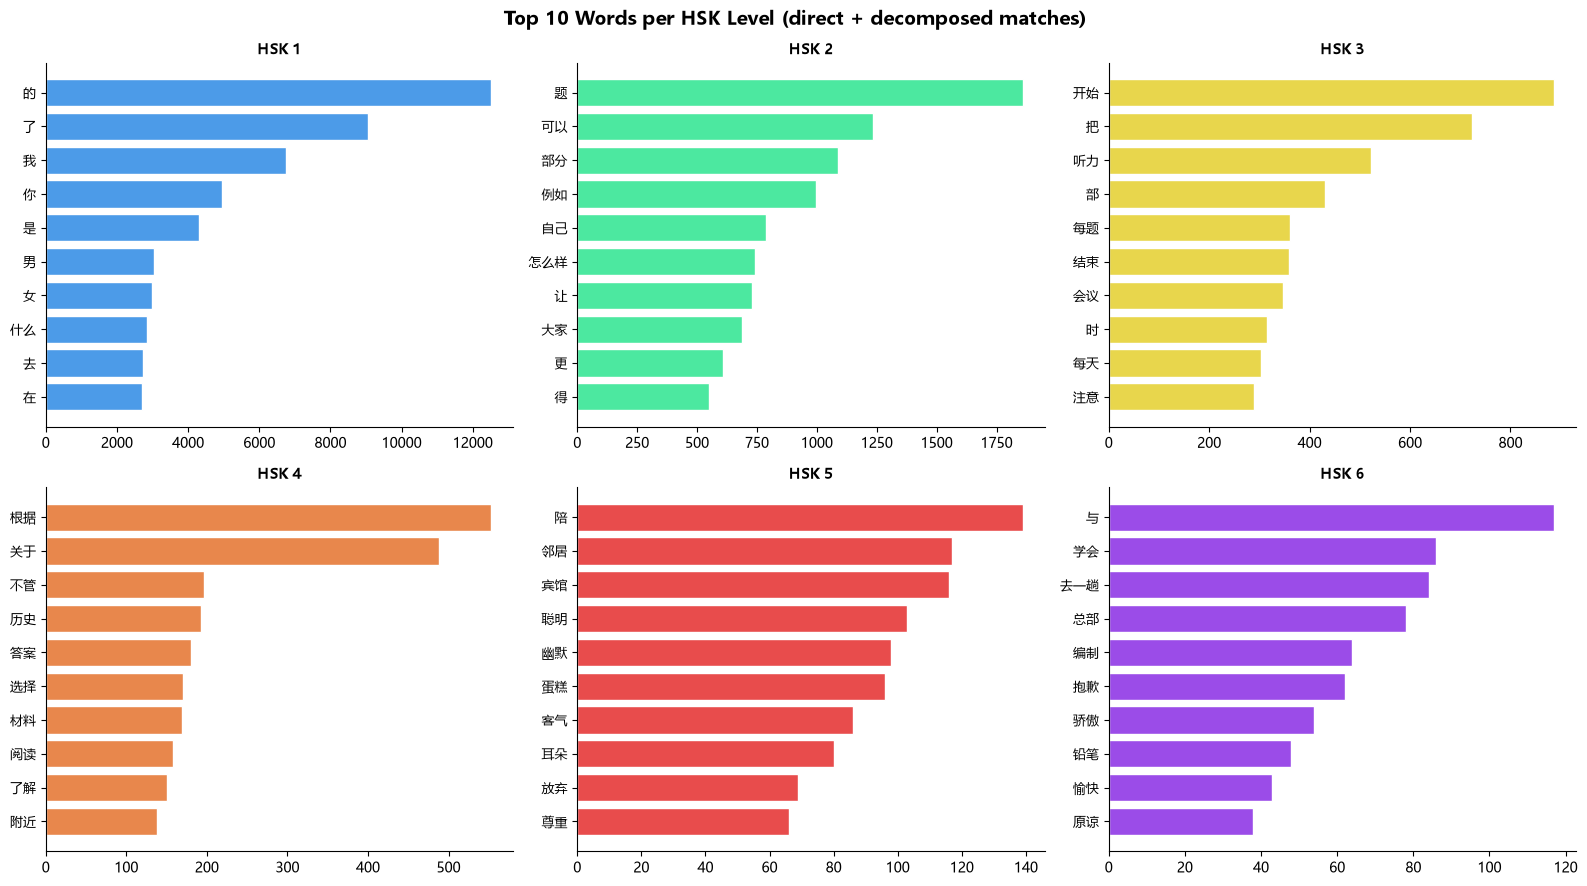

In [3]:
by_level = (
    df[df["effective_level"].notna()]
    .groupby(["effective_level", "word"], as_index=False)["count"].sum()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
levels = sorted(by_level["effective_level"].unique())
palette = {1.0: "#4C9BE8", 2.0: "#4CE8A0", 3.0: "#E8D64C", 4.0: "#E8874C", 5.0: "#E84C4C", 6.0: "#9B4CE8"}

for ax, lvl in zip(axes.flat, levels):
    sub = by_level[by_level["effective_level"] == lvl].sort_values("count", ascending=False).head(10)
    ax.barh(sub["word"][::-1], sub["count"][::-1], color=palette.get(lvl, "#888"), edgecolor="white")
    ax.set_title(f"HSK {int(lvl)}", fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Top 10 Words per HSK Level (direct + decomposed matches)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_top10_per_level.png", dpi=150)
plt.show()


## 3 -- Top 10 words: reading vs listening

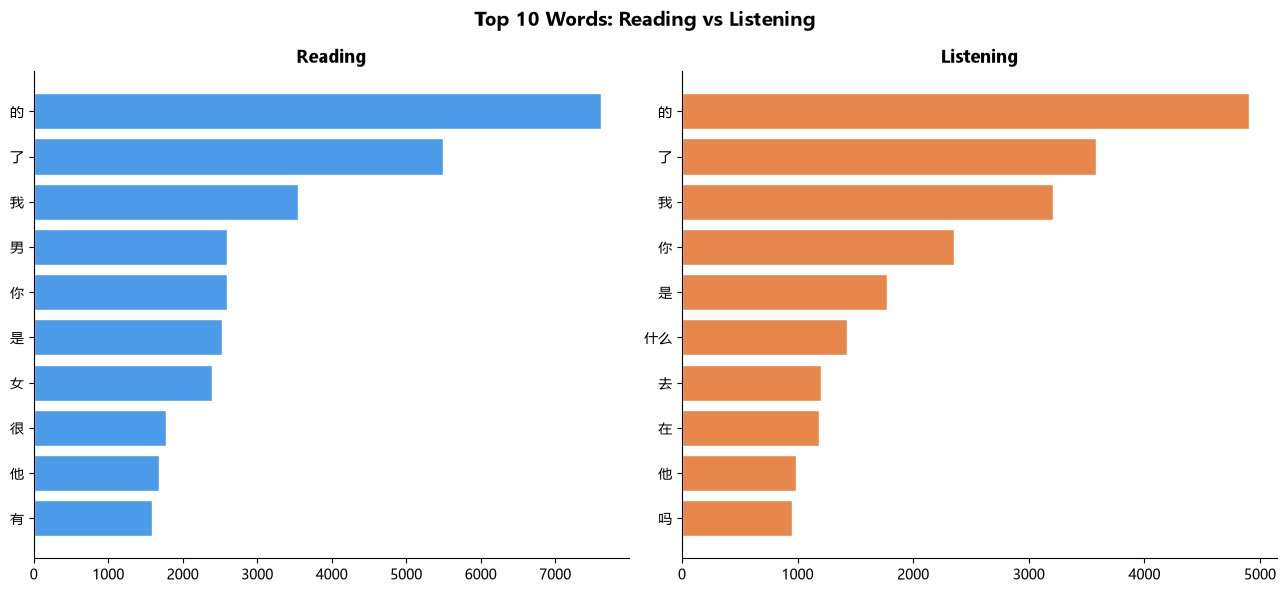

In [4]:
by_source = df.groupby(["source_type", "word"], as_index=False)["count"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
src_colors = {"reading": "#4C9BE8", "listening": "#E8874C"}

for ax, src in zip(axes, ["reading", "listening"]):
    sub = by_source[by_source["source_type"] == src].sort_values("count", ascending=False).head(10)
    ax.barh(sub["word"][::-1], sub["count"][::-1], color=src_colors[src], edgecolor="white")
    ax.set_title(src.capitalize(), fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 Words: Reading vs Listening", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_top10_reading_vs_listening.png", dpi=150)
plt.show()


## 4 -- Wordlist match coverage

How much of the corpus resolved to an HSK level, split by `match_type`
(`direct` / `decomposed` / `unmatched`), for both unique words and token
occurrences.

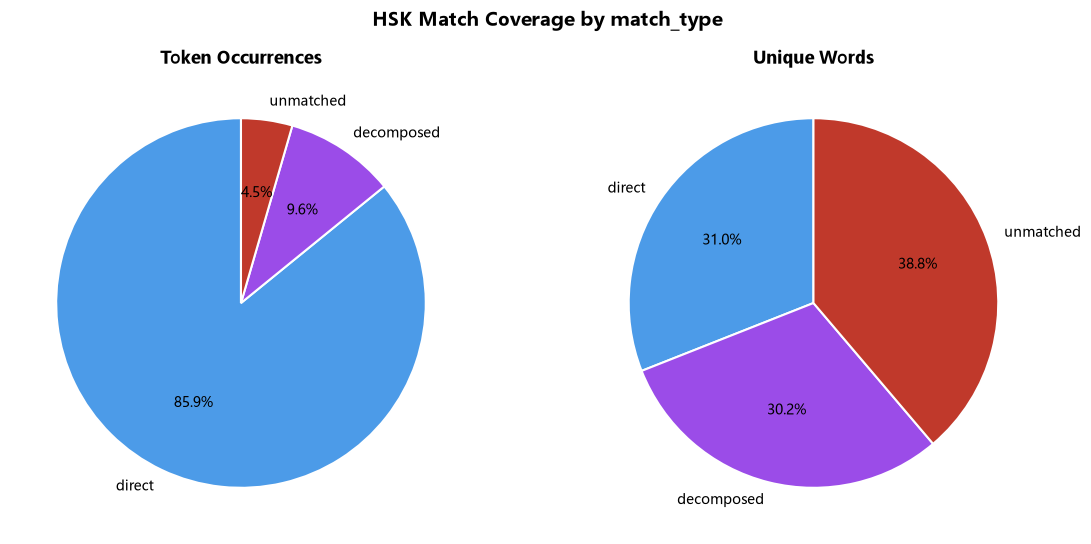

match_type
decomposed     26878
direct        239324
unmatched      12503
Name: count, dtype: int64 

match_type
decomposed    2293
direct        2351
unmatched     2943
Name: word, dtype: int64


In [5]:
tok_by_type = df.groupby("match_type")["count"].sum()
uniq_by_type = df.groupby("match_type")["word"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
mt_colors = {"direct": "#4C9BE8", "decomposed": "#9B4CE8", "unmatched": "#C0392B"}
order = ["direct", "decomposed", "unmatched"]

for ax, series, title in zip(axes, [tok_by_type, uniq_by_type], ["Token Occurrences", "Unique Words"]):
    vals = series.reindex(order)
    pct = 100 * vals / vals.sum()
    wedges, _, autotexts = ax.pie(
        vals, labels=order, autopct=lambda p: f"{p:.1f}%",
        colors=[mt_colors[k] for k in order], startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.suptitle("HSK Match Coverage by match_type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_match_coverage.png", dpi=150)
plt.show()

print(tok_by_type, "\n")
print(uniq_by_type)


## 5 -- Frequent words NOT in the official wordlist

Feeds the same idea as the planned `/api/compare/wordlist-vs-actual`
endpoint: which words show up often in real exams but aren't HSK vocabulary
at all (`match_type == "unmatched"`)?

,word,count
1060,小王,306
295,会议室,200
839,填写,137
1282,总能,119
471,分三,114
1610,有点,111
170,书写,99
2713,选出,96
70,下列,95
634,发给,93


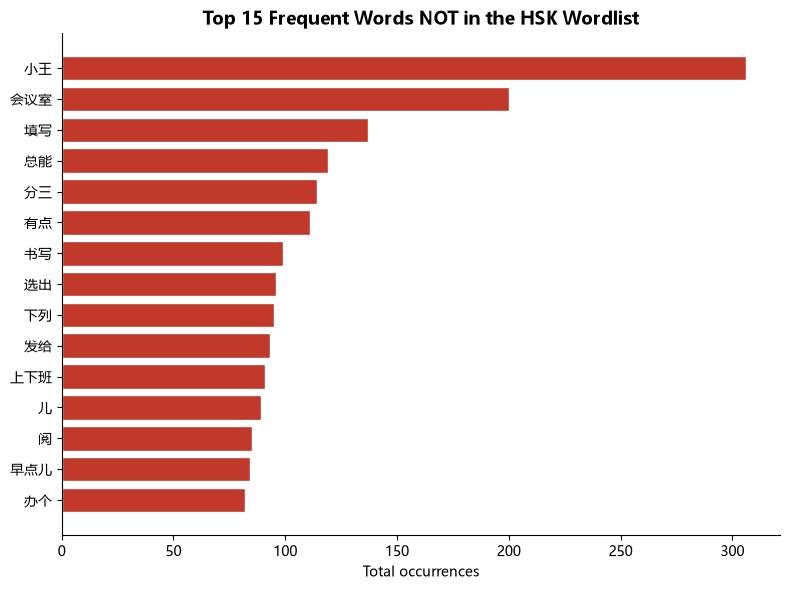

In [6]:
unmatched_top = (
    df[df["match_type"] == "unmatched"]
    .groupby("word", as_index=False)["count"].sum()
    .sort_values("count", ascending=False)
    .head(15)
)
display(unmatched_top)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(unmatched_top["word"][::-1], unmatched_top["count"][::-1], color="#C0392B", edgecolor="white")
ax.set_xlabel("Total occurrences")
ax.set_title("Top 15 Frequent Words NOT in the HSK Wordlist", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_top15_unmatched.png", dpi=150)
plt.show()


## 6 -- Frequency distribution (Zipf check)

Rank-frequency plot on a log-log scale. Natural language word frequencies
follow Zipf's law (frequency inversely proportional to rank) -- this is a
sanity check that the corpus behaves like real language, not degenerate
noise from a broken extraction step.

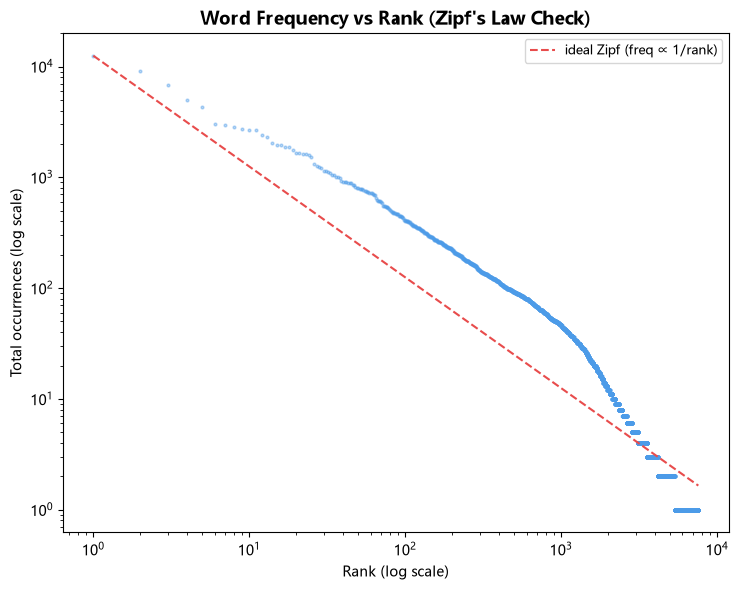

In [7]:
word_totals = df.groupby("word")["count"].sum().sort_values(ascending=False).reset_index()
word_totals["rank"] = range(1, len(word_totals) + 1)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.loglog(word_totals["rank"], word_totals["count"], marker=".", linestyle="none",
          alpha=0.4, color="#4C9BE8", markersize=4)

# reference Zipf line: freq = C / rank
C = word_totals["count"].iloc[0]
ref_rank = word_totals["rank"]
ax.loglog(ref_rank, C / ref_rank, color="#E84C4C", linewidth=1.5, linestyle="--", label="ideal Zipf (freq \u221d 1/rank)")

ax.set_xlabel("Rank (log scale)")
ax.set_ylabel("Total occurrences (log scale)")
ax.set_title("Word Frequency vs Rank (Zipf's Law Check)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_zipf_rank_frequency.png", dpi=150)
plt.show()


## 7 -- Words per HSK level covered by the corpus vs full official wordlist

,wordlist_total,seen_in_exams
1,497,1453
2,758,1312
3,962,776
4,1003,566
5,1317,288
6,2872,249


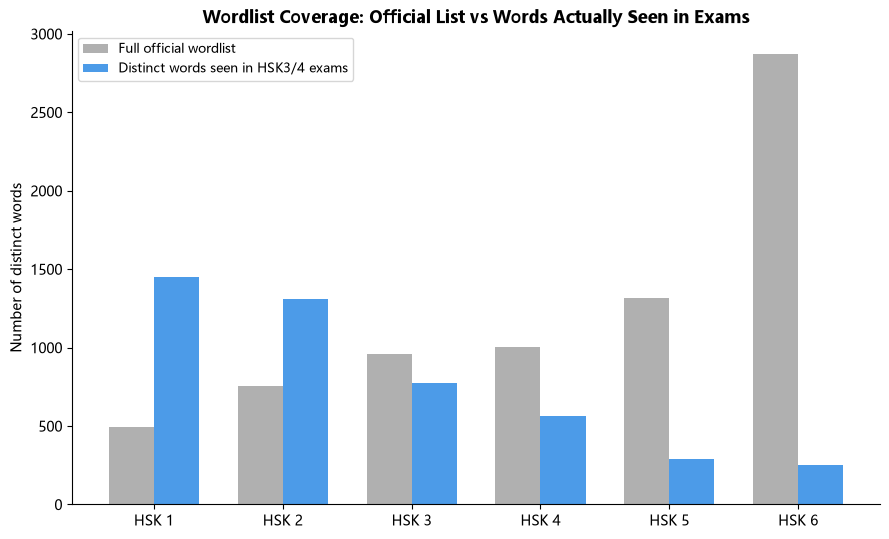

In [8]:
wordlist_by_level = df_wordlist.groupby("level").size().rename("wordlist_total")
corpus_by_level = (
    df[df["effective_level"].notna()]
    .drop_duplicates("word")
    .groupby("effective_level").size().rename("seen_in_exams")
)
compare_levels = pd.concat([wordlist_by_level, corpus_by_level], axis=1).fillna(0).astype(int)
compare_levels.index = compare_levels.index.astype(int)
display(compare_levels)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = compare_levels.index.astype(str)
w = 0.35
idx = range(len(x))
ax.bar([i - w/2 for i in idx], compare_levels["wordlist_total"], w, label="Full official wordlist", color="#B0B0B0")
ax.bar([i + w/2 for i in idx], compare_levels["seen_in_exams"], w, label="Distinct words seen in HSK3/4 exams", color="#4C9BE8")
ax.set_xticks(list(idx))
ax.set_xticklabels([f"HSK {lv}" for lv in x])
ax.set_ylabel("Number of distinct words")
ax.set_title("Wordlist Coverage: Official List vs Words Actually Seen in Exams", fontsize=12.5, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_wordlist_vs_seen.png", dpi=150)
plt.show()


## 8 -- Save summary

Top 50 words overall, with level / match_type / source breakdown, for quick
reference without re-running the whole notebook.

In [9]:
summary = (
    df.groupby("word", as_index=False)
    .agg(
        total_count=("count", "sum"),
        exam_count=("exam_id", "nunique"),
        effective_level=("effective_level", "first"),
        match_type=("match_type", "first"),
    )
    .sort_values("total_count", ascending=False)
    .head(50)
)
summary.to_csv(PROCESSED_DIR / "top_words_summary.csv", index=False, encoding="utf-8-sig")
print(f"Saved top 50 words -> {PROCESSED_DIR / 'top_words_summary.csv'}")
display(summary.head(10))


Saved top 50 words -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\top_words_summary.csv


,word,total_count,exam_count,effective_level,match_type
5592,的,12518,65,1.0,direct
812,了,9069,65,1.0,direct
3906,我,6756,65,1.0,direct
1161,你,4940,65,1.0,direct
4513,是,4297,65,1.0,direct
5522,男,3043,65,1.0,direct
2965,女,2990,65,1.0,direct
1005,什么,2836,65,1.0,direct
2040,去,2745,65,1.0,direct
2572,在,2696,65,1.0,direct


## 9 -- Top 10 words by exam HSK level (HSK3 papers vs HSK4 papers)

Not to be confused with section 2 (which splits by the *word's own* HSK
level). This splits by which **exam paper** the word came from -- HSK3
exams vs HSK4 exams -- since harder exams should skew toward higher-level
vocabulary even for the same frequent words.

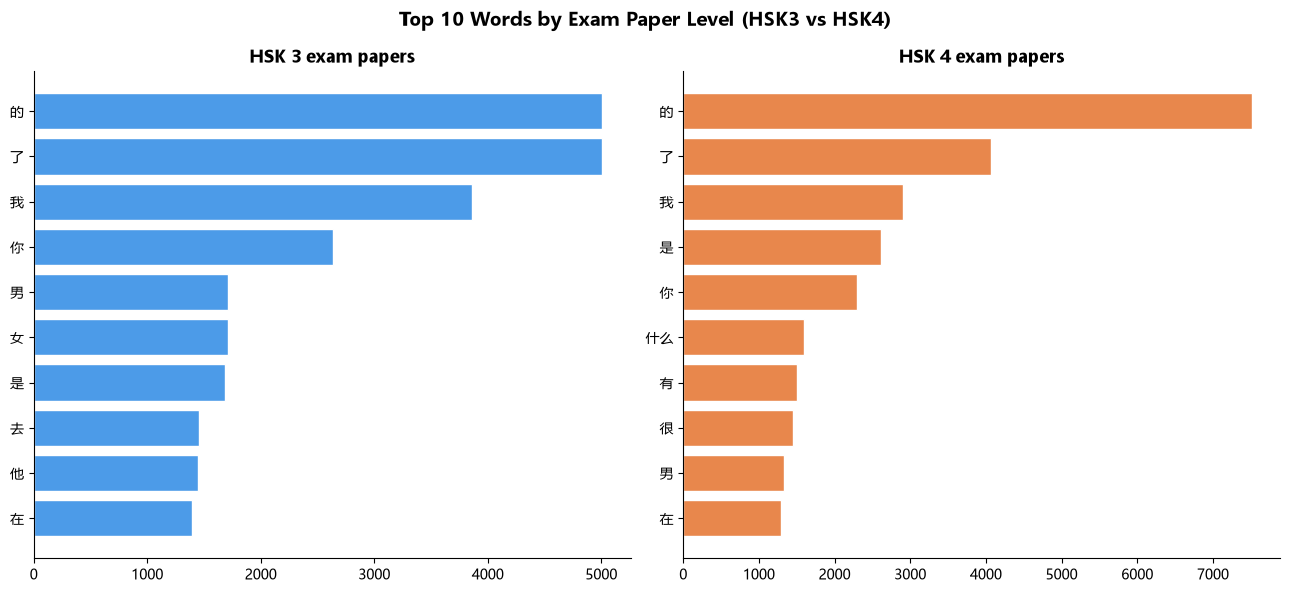

In [10]:
by_exam_level = df.groupby(["hsk_level", "word"], as_index=False)["count"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
exam_lvl_colors = {3: "#4C9BE8", 4: "#E8874C"}

for ax, lvl in zip(axes, sorted(by_exam_level["hsk_level"].unique())):
    sub = by_exam_level[by_exam_level["hsk_level"] == lvl].sort_values("count", ascending=False).head(10)
    ax.barh(sub["word"][::-1], sub["count"][::-1], color=exam_lvl_colors[lvl], edgecolor="white")
    ax.set_title(f"HSK {lvl} exam papers", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Top 10 Words by Exam Paper Level (HSK3 vs HSK4)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_top10_by_exam_level.png", dpi=150)
plt.show()


## 10 -- Top word per exam file

Each `(exam_id, source_type)` pair is a distinct source file (e.g. the PDF
`H31327.pdf` and its paired listening audio are two separate files sharing
`exam_id=H31327`). This table shows, for every one of the 130 files, which
word occurred the most times in that specific file.

In [11]:
per_file = (
    df.groupby(["exam_id", "source_type", "hsk_level", "word"], as_index=False)["count"].sum()
)
top_per_file = (
    per_file.sort_values("count", ascending=False)
    .groupby(["exam_id", "source_type"], as_index=False)
    .first()
    .sort_values(["hsk_level", "exam_id", "source_type"])
    .rename(columns={"word": "top_word", "count": "top_word_count"})
)

print(f"{len(top_per_file)} files (expected 130 = 65 exams x 2 source types)")
top_per_file.to_csv(PROCESSED_DIR / "top_word_per_file.csv", index=False, encoding="utf-8-sig")
print(f"Saved -> {PROCESSED_DIR / 'top_word_per_file.csv'}")
display(top_per_file)


130 files (expected 130 = 65 exams x 2 source types)
Saved -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\top_word_per_file.csv


,exam_id,source_type,hsk_level,top_word,top_word_count
0,H30000,listening,3,的,70
1,H30000,reading,3,的,105
2,H31001,listening,3,的,80
3,H31001,reading,3,的,125
4,H31002,listening,3,的,72
...,...,...,...,...,...
125,H41553B,reading,4,的,182
126,H41553C,listening,4,的,92
127,H41553C,reading,4,的,207
128,H41553D,listening,4,的,91


## 11 -- Heatmap: top overall words across files

Rather than 130 separate bar charts, a heatmap shows how the top 15
overall words (from section 1) are distributed across every exam file --
useful for spotting whether a "top word" is evenly spread or actually
concentrated in just a few exams.

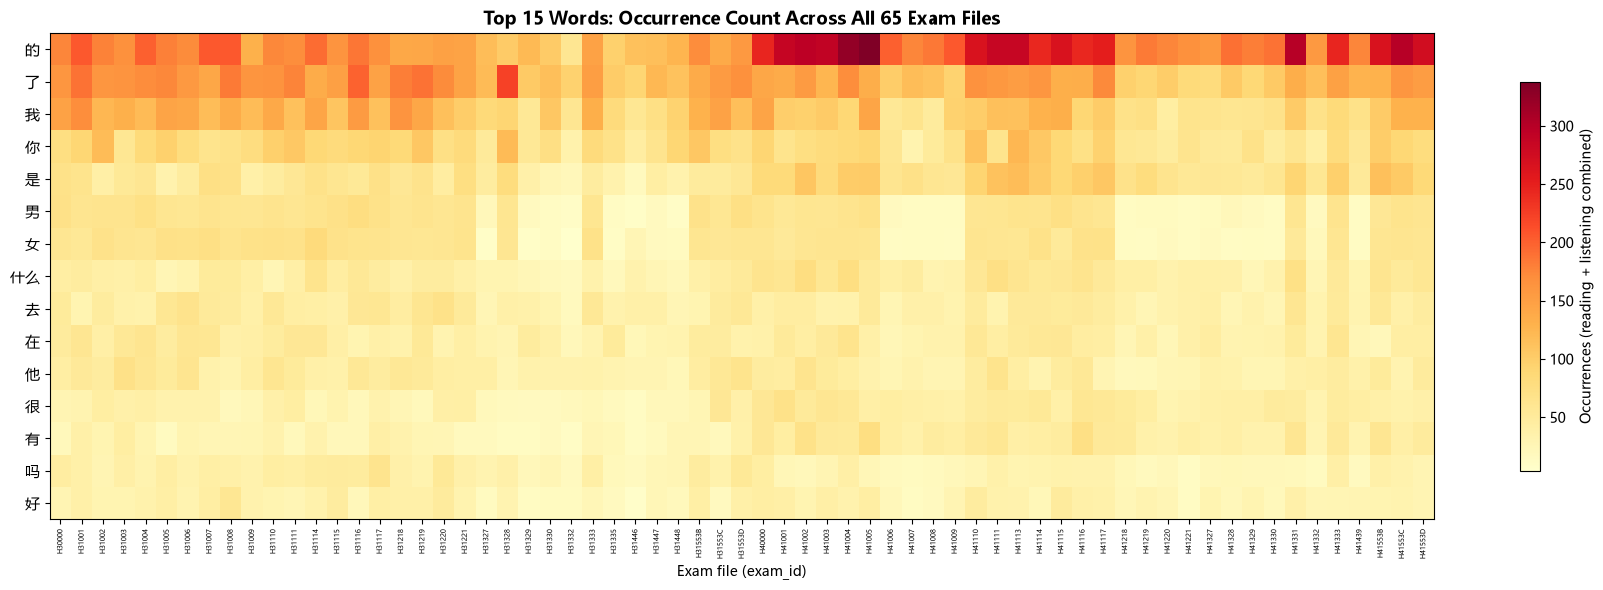

In [12]:
top15_words = agg.sort_values("total_count", ascending=False).head(15)["word"].tolist()

pivot = (
    df[df["word"].isin(top15_words)]
    .groupby(["word", "exam_id"], as_index=False)["count"].sum()
    .pivot(index="word", columns="exam_id", values="count")
    .reindex(top15_words)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=5, rotation=90)
ax.set_xlabel("Exam file (exam_id)")
ax.set_title("Top 15 Words: Occurrence Count Across All 65 Exam Files", fontsize=13, fontweight="bold")
fig.colorbar(im, ax=ax, label="Occurrences (reading + listening combined)", shrink=0.8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_top15_heatmap_by_file.png", dpi=150)
plt.show()
